<a href="https://colab.research.google.com/github/w4ib4/2438446_SrijanTamang/blob/main/SrijanTamang_Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI Datasets/Copy of devnagari digit.zip"
extract_path = "/content/drive/MyDrive/AI Datasets/workshop4"

os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [3]:
TRAIN_DIR = '/content/drive/MyDrive/AI Datasets/workshop4/DevanagariHandwrittenDigitDataset/Train'
TEST_DIR  = '/content/drive/MyDrive/AI Datasets/workshop4/DevanagariHandwrittenDigitDataset/Test'

print("Train classes:", sorted(os.listdir(TRAIN_DIR)))
print("Test  classes:", sorted(os.listdir(TEST_DIR)))

Train classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Test  classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU : {'YES ✓ ' + gpus[0].name if gpus else 'NO — go Runtime → Change runtime type → T4 GPU'}")

TensorFlow : 2.19.0
GPU : YES ✓ /physical_device:GPU:0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image

IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img) / 255.0
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {filename}: {e}")

    return np.array(images), np.array(labels)

print("Loading training images... (takes 1-2 mins)")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
print(f"  Done: {len(x_train_raw)} images")

print("Loading test images...")
x_test_raw, y_test_raw = load_images_from_folder(TEST_DIR)
print(f"  Done: {len(x_test_raw)} images")

Loading training images... (takes 1-2 mins)
  Done: 17000 images
Loading test images...
  Done: 3000 images


In [6]:
# Flatten 28x28 → 784
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}")
print(f"y_test  : {y_test.shape}")


x_train : (17000, 784)
y_train : (17000, 10)
x_test  : (3000, 784)
y_test  : (3000, 10)


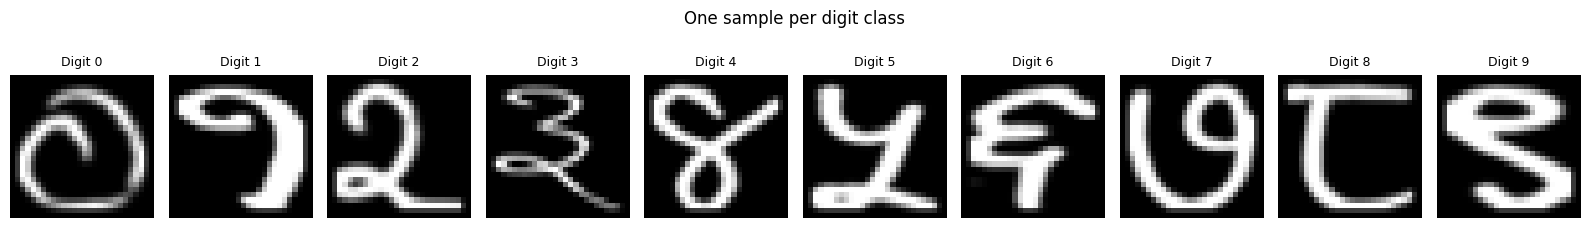

In [7]:
plt.figure(figsize=(16, 2.5))
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    plt.subplot(1, 10, digit + 1)
    plt.imshow(x_train_raw[idx], cmap='gray')
    plt.title(f'Digit {digit}', fontsize=9)
    plt.axis('off')
plt.suptitle('One sample per digit class', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),

    keras.layers.Dense(64,  activation='sigmoid', name='hidden_1'),
    keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),
    keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),

    keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output'),
], name='Devnagari_FCN')

model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")
print("  Optimizer : adam")
print("  Loss      : categorical_crossentropy")
print("  Metric    : accuracy")

Model compiled!
  Optimizer : adam
  Loss      : categorical_crossentropy
  Metric    : accuracy


In [10]:
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")
print(f"Epochs trained : {len(history.history['loss'])}")
print(f"Best val_acc   : {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2590 - loss: 2.0214
Epoch 1: val_loss improved from None to 7.14741, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4494 - loss: 1.6823 - val_accuracy: 0.0000e+00 - val_loss: 7.1474
Epoch 2/20
 88/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.7117
Epoch 2: val_loss did not improve from 7.14741
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8234 - loss: 0.5452 - val_accuracy: 0.0000e+00 - val_loss: 8.3026
Epoch 3/20
 87/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8824 - loss: 0.3338
Epoch 3: val_loss did not improve from 7.14741
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9003 - loss: 0.3100 - val_accuracy: 0.0000e+00 - val_loss: 8.6879
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9360 - loss: 0.2277
Epoch 4: val_loss did not improve from 7.14

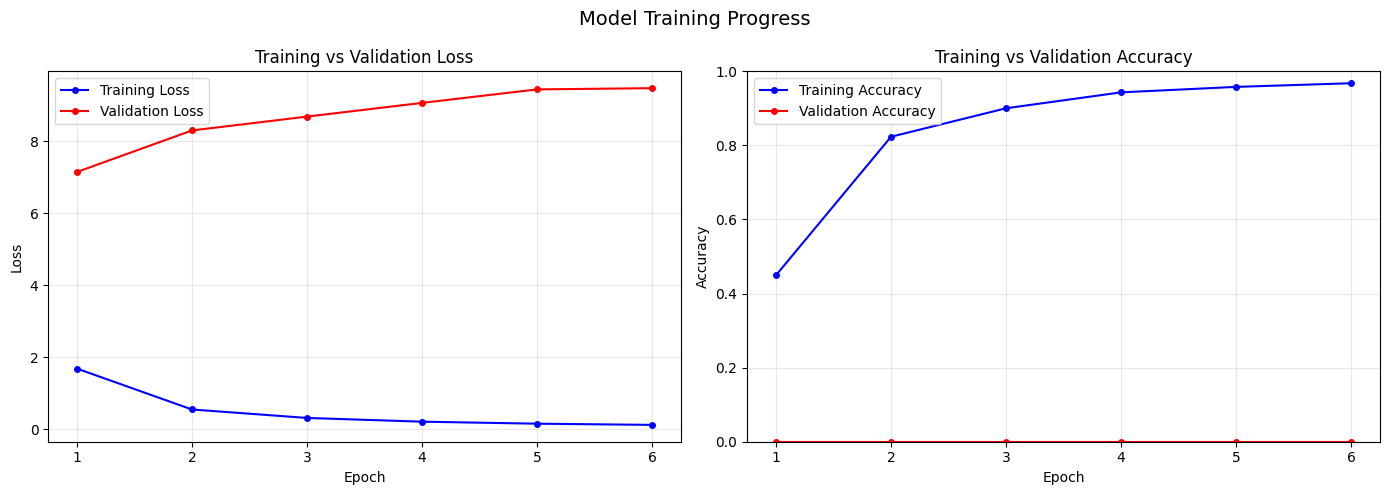

Saved: training_curves.png ✓


In [11]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
x_axis     = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x_axis, train_loss, 'b-o', markersize=4, label='Training Loss')
ax1.plot(x_axis, val_loss,   'r-o', markersize=4, label='Validation Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x_axis, train_acc, 'b-o', markersize=4, label='Training Accuracy')
ax2.plot(x_axis, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png ✓")

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"{'='*40}")

94/94 - 1s - 12ms/step - accuracy: 0.6103 - loss: 2.1369

  Test Loss     : 2.1369
  Test Accuracy : 61.03%


In [13]:
# Save
model.save('devnagari_fcn_model.h5')
print("Model saved: devnagari_fcn_model.h5 ✓")

# Load
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully! ✓")

# Re-evaluate
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"\nOriginal accuracy : {test_accuracy*100:.2f}%")
print(f"Loaded   accuracy : {loaded_acc*100:.2f}%")
print(f"Match             : {'YES ✓' if abs(test_accuracy - loaded_acc) < 1e-4 else 'NO ✗'}")

Model saved: devnagari_fcn_model.h5 ✓
Model loaded successfully! ✓

Original accuracy : 61.03%
Loaded   accuracy : 61.03%
Match             : YES ✓


In [14]:
from google.colab import files
files.download('devnagari_fcn_model.h5')
print("Downloading devnagari_fcn_model.h5 — save this file!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

correct   = np.sum(predicted_labels == true_labels)
incorrect = np.sum(predicted_labels != true_labels)
print(f"Correct  : {correct}  ({correct/len(predicted_labels)*100:.1f}%)")
print(f"Wrong    : {incorrect} ({incorrect/len(predicted_labels)*100:.1f}%)")

Correct  : 1831  (61.0%)
Wrong    : 1169 (39.0%)


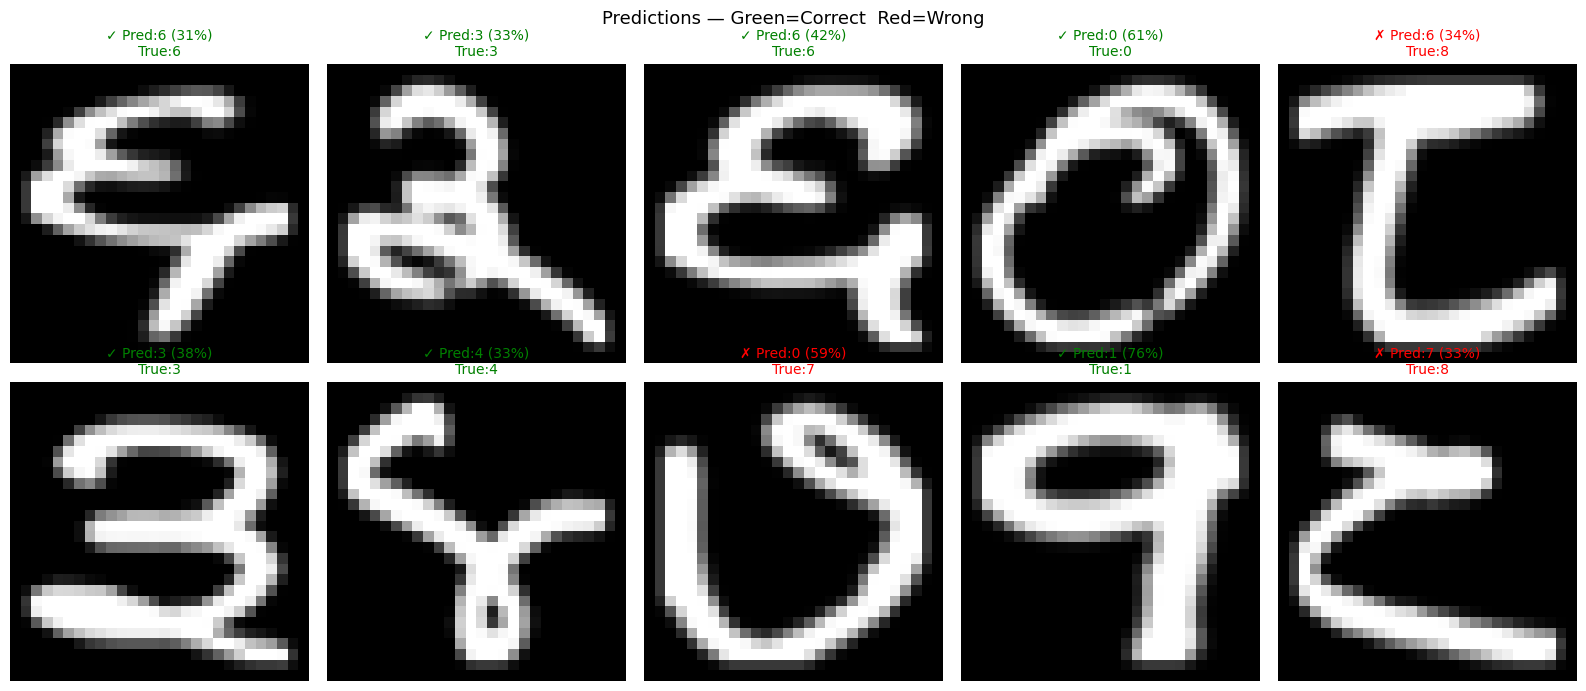

Saved: predictions_sample.png ✓


In [16]:
np.random.seed(42)
indices = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, idx in enumerate(indices):
    pred   = predicted_labels[idx]
    truth  = true_labels[idx]
    conf   = predictions[idx][pred] * 100
    colour = 'green' if pred == truth else 'red'
    mark   = '✓' if pred == truth else '✗'

    axes[i].imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    axes[i].set_title(f"{mark} Pred:{pred} ({conf:.0f}%)\nTrue:{truth}",
                      color=colour, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Predictions — Green=Correct  Red=Wrong', fontsize=13)
plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predictions_sample.png ✓")

In [17]:
print("Per-digit accuracy:")
print("-" * 30)
for digit in range(10):
    mask      = (true_labels == digit)
    n_correct = (predicted_labels[mask] == digit).sum()
    acc       = n_correct / mask.sum() * 100
    bar       = '█' * int(acc / 5)
    print(f"  Digit {digit} : {acc:6.2f}%  {bar}")

Per-digit accuracy:
------------------------------
  Digit 0 :  97.33%  ███████████████████
  Digit 1 :  97.67%  ███████████████████
  Digit 2 :   2.33%  
  Digit 3 :  88.00%  █████████████████
  Digit 4 :  95.00%  ███████████████████
  Digit 5 :  69.00%  █████████████
  Digit 6 :  78.67%  ███████████████
  Digit 7 :  82.33%  ████████████████
  Digit 8 :   0.00%  
  Digit 9 :   0.00%  


In [18]:
from google.colab import files
files.download('training_curves.png')
files.download('predictions_sample.png')
files.download('devnagari_fcn_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>